=== STATISTIQUES GLOBALES ===
\n--- DENSITY ---
MAE               : 7.808271e-08
RMSE              : 2.794328e-04
L_inf (Max Error) : 1.000000e+00
Relative L2       : 1.164481e-03
Pearson Corr      : 9.999993e-01
\n--- VELOCITY ---
MAE               : 7.563625e-07
RMSE              : 3.430442e-03
L_inf (Max Error) : 2.538723e+01
Relative L2       : 3.113284e-03
Pearson Corr      : 9.999951e-01
\n--- DIRECTIVITY ---
MAE               : 7.400397e-07
RMSE              : 3.596258e-03
L_inf (Max Error) : 2.973412e+01
Relative L2       : 2.978312e-03
Pearson Corr      : 9.999956e-01


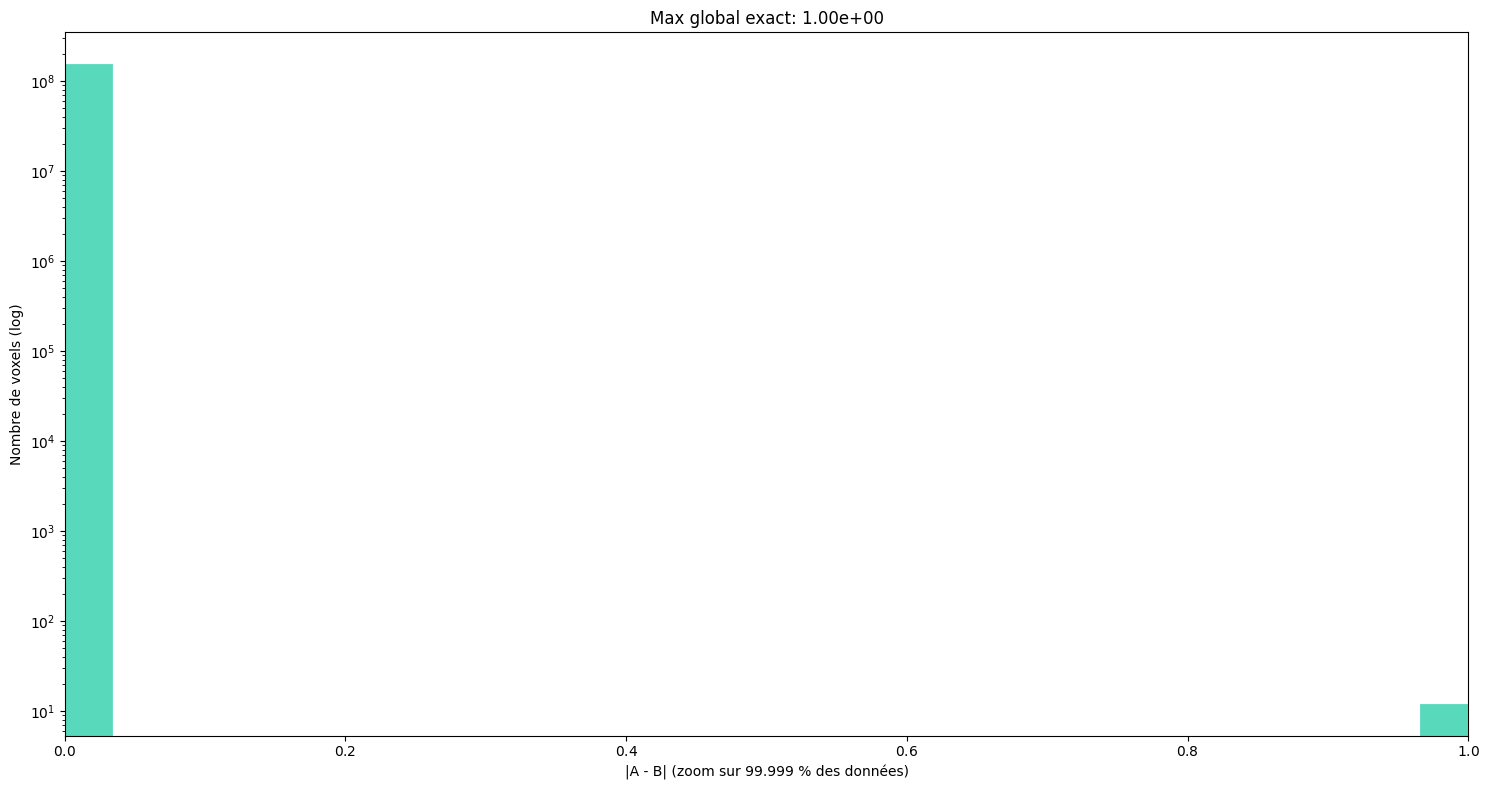

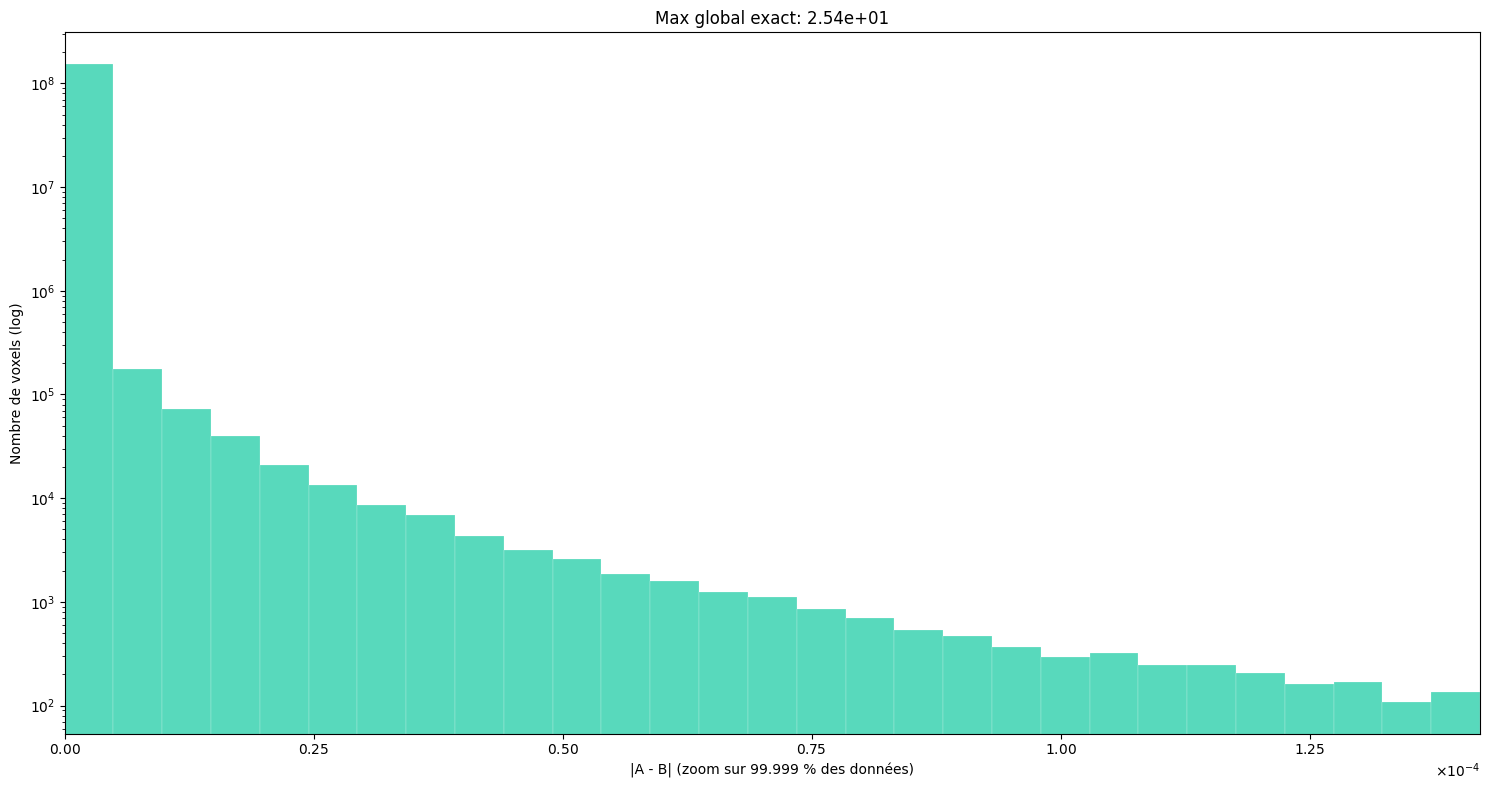

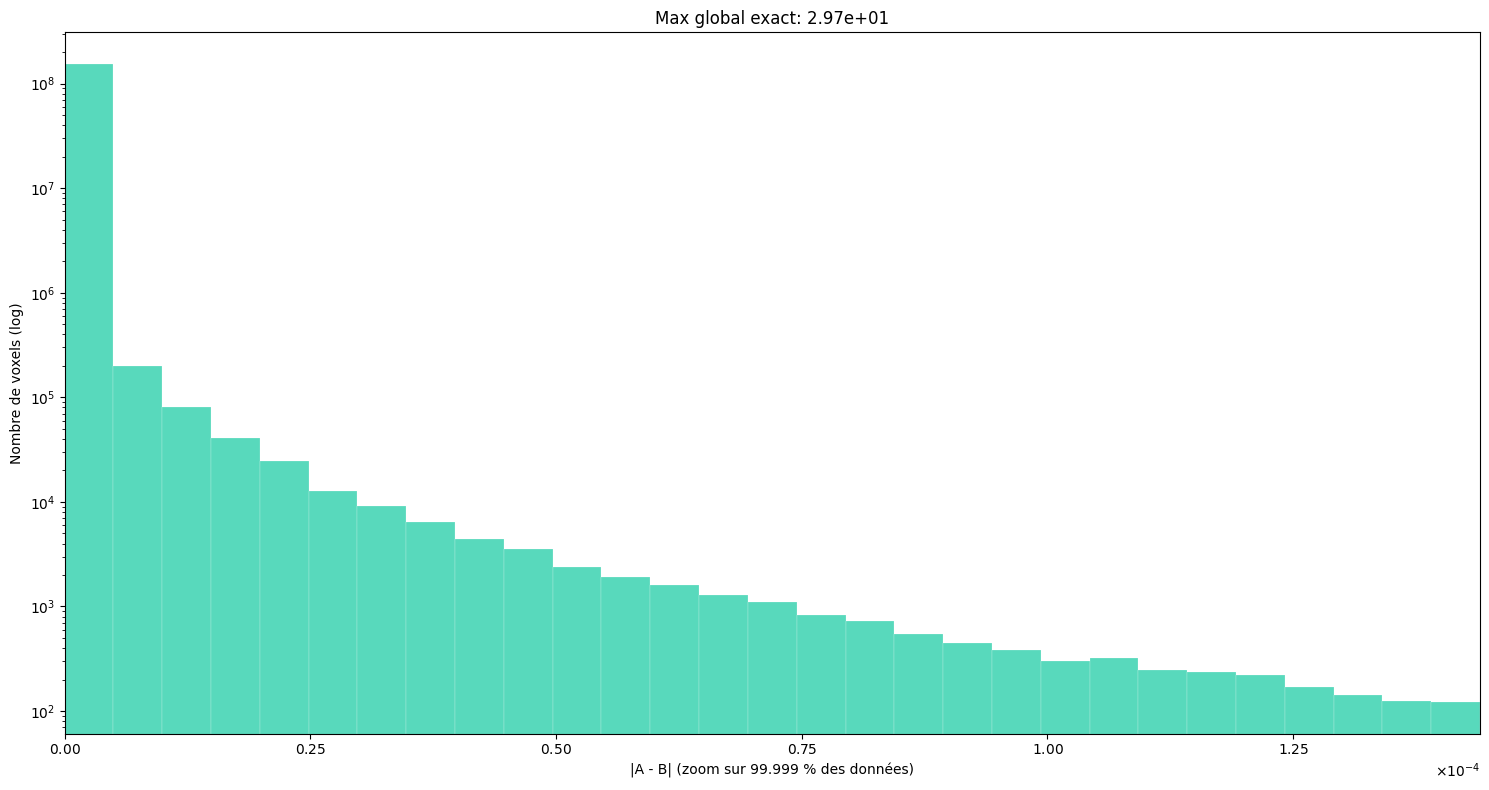

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

path_A = "../../../results/config_222/volume"
path_B = "../../../results/Numpy/volume"

variables = ["density", "velocity", "directivity"]

def load_npy(folder, name):
    path = os.path.join(folder, f"{name}.npy")
    if not os.path.isfile(path):
        print(f"⚠️ Fichier manquant : {path}")
        return None
    return np.load(path)

# Chargement de toutes les données sous forme de dictionnaire
data_A = {var: load_npy(path_A, var) for var in variables}
data_B = {var: load_npy(path_B, var) for var in variables}

# Filtrer les variables qui n'ont pas pu être chargées
variables = [v for v in variables if data_A[v] is not None and data_B[v] is not None]

def compute_metrics(A, B):
    diff = A - B
    abs_diff = np.abs(diff)
    
    norm_A = np.linalg.norm(A)
    rel_l2 = np.linalg.norm(diff) / norm_A if norm_A > 1e-12 else np.nan
    
    return {
        "MAE": np.mean(abs_diff),
        "RMSE": np.sqrt(np.mean(diff**2)),
        "L_inf (Max Error)": np.max(abs_diff),
        "Relative L2": rel_l2,
        "Pearson Corr": np.corrcoef(A.ravel(), B.ravel())[0, 1]
    }

print("=== STATISTIQUES GLOBALES ===")
for var in variables:
    print(f"\\n--- {var.upper()} ---")
    metrics = compute_metrics(data_A[var], data_B[var])
    for k, v in metrics.items():
        print(f"{k:<18}: {v:.6e}")


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import numpy as np
import matplotlib.pyplot as plt

for var in variables:
    A = data_A[var]
    B = data_B[var]
    err_abs = np.abs(A - B)
    err_flat = err_abs.flatten()
    
    max_val = np.max(err_abs)

    fig, ax = plt.subplots(figsize=(15, 8))
    
    limit_x = np.percentile(err_flat, 99.999)
    if limit_x == 0: 
        limit_x = max_val
        
    ax.hist(err_flat, bins="auto", range=(0, limit_x), log=True, 
            color='#11caa0', alpha=0.7, edgecolor='white', linewidth=0.2)

    ax.set_xlim(0, limit_x)
    
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)

    plt.xlabel(f"|A - B| (zoom sur 99.999 % des données)")
    plt.ylabel("Nombre de voxels (log)")
    plt.title(f"Max global exact: {max_val:.2e}")
    
    plt.tight_layout()
    plt.savefig(f"distrib_{var}.png")
    plt.show()